# Regime-Switching SSMs with `RSSSM`: a first example

This tutorial introduces `hssm.RSSSM`, the high-level class for **regime-switching sequential sampling models**. Each trial belongs to one of `K` hidden cognitive *regimes* that evolve as a Markov chain; within a regime the `(rt, response)` emission is a standard SSM (here a DDM) whose drift rate `v` switches across regimes while the other parameters are shared.

It mirrors the hand-built model in *"Hidden Markov Models with DDM emissions"* — but instead of assembling the PyMC graph by hand, `RSSSM` builds it for you, marginalising the discrete regimes out with the forward algorithm so that NUTS only ever sees continuous parameters.

We use a single participant, `K = 2` regimes, and switch only on the drift rate `v`.

In [1]:
import numpy as np
import pandas as pd
import arviz as az

import hssm

%config InlineBackend.figure_format = 'retina'

## 1. Simulate regime-switching data

Two regimes with drift rates `v = 0.2` (slow/"distracted") and `v = 1.5` (fast/"attentive"); the boundary `a`, starting point `z`, and non-decision time `t` are shared. The regime sequence is a sticky 2-state Markov chain.

In [2]:
def simulate_regime_switching_ddm(n_trials, v_per_regime, a, z, t, P, pi0, seed=0):
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])
    data = np.empty((n_trials, 2))
    for k in range(K):
        mask = regimes == k
        n_k = int(mask.sum())
        if n_k:
            sims = hssm.simulate_data(
                model="ddm",
                theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
            data[mask] = sims
    return pd.DataFrame(data, columns=["rt", "response"]), regimes


P = np.array([[0.95, 0.05], [0.10, 0.90]])
pi0 = np.array([0.8, 0.2])
df, true_regimes = simulate_regime_switching_ddm(
    n_trials=500, v_per_regime=[0.2, 1.5], a=0.8, z=0.5, t=0.3, P=P, pi0=pi0, seed=1
)
df.head()

,rt,response
0,0.618584,-1.0
1,0.756348,1.0
2,0.605561,1.0
3,2.095907,1.0
4,1.193549,1.0


## 2. Build and fit the model

The drift rate is listed in `switching_params`, so it becomes a length-`K` vector inferred per regime; `a`, `z`, `t` are shared. `RSSSM` automatically applies an `ordered` transform to `v` to break the label-switching symmetry (regime 0 is the low-drift regime).

In [3]:
model = hssm.RSSSM(
    data=df,
    model="ddm",
    K=2,
    switching_params=["v"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


In [4]:
idata = model.sample(draws=500, tune=500, chains=2, random_seed=42)
model.summary()

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   0%|          | 1/1000 [00:01<18:34,  1.12s/it, 1 steps of size 2.34e+00. acc. prob=0.00]

warmup:   1%|          | 9/1000 [00:01<01:44,  9.44it/s, 63 steps of size 1.79e-02. acc. prob=0.58]

warmup:   1%|▏         | 13/1000 [00:01<01:13, 13.48it/s, 31 steps of size 1.35e-02. acc. prob=0.64]

...

sample:  98%|█████████▊| 982/1000 [00:12<00:00, 102.28it/s, 7 steps of size 3.90e-01. acc. prob=0.92]

sample: 100%|█████████▉| 995/1000 [00:13<00:00, 108.48it/s, 7 steps of size 3.90e-01. acc. prob=0.92]

sample: 100%|██████████| 1000/1000 [00:13<00:00, 76.42it/s, 15 steps of size 3.90e-01. acc. prob=0.92]

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,500,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t,0.305,0.009,0.289,0.320,0.000,0.000,506.0,576.0,1.00
"P[0, 0]",0.918,0.033,0.848,0.968,0.001,0.001,558.0,474.0,1.00
"P[0, 1]",0.082,0.033,0.032,0.152,0.001,0.001,558.0,474.0,1.00
"P[1, 0]",0.144,0.041,0.074,0.224,0.002,0.001,700.0,675.0,1.01
"P[1, 1]",0.856,0.041,0.776,0.926,0.002,0.001,700.0,675.0,1.01
z,0.507,0.017,0.473,0.536,0.001,0.000,608.0,569.0,1.00
a,0.825,0.022,0.782,0.867,0.001,0.001,496.0,597.0,1.00
v[0],0.072,0.151,-0.195,0.355,0.007,0.005,461.0,610.0,1.00
v[1],1.757,0.417,1.034,2.506,0.023,0.015,371.0,511.0,1.00


The two drift rates are recovered and ordered (`v[0] < v[1]`), close to the true `[0.2, 1.5]`, alongside the shared `a`, `z`, `t` and the transition matrix `P`.

## 3. Recover the latent regimes (FFBS)

NUTS marginalised the regimes out, so the posterior contains only `v`, `a`, `z`, `t`, `P`. `infer_regimes` reconstructs a posterior over the regime sequence *after* sampling, using Forward-Filter Backward-Sample on each posterior draw.

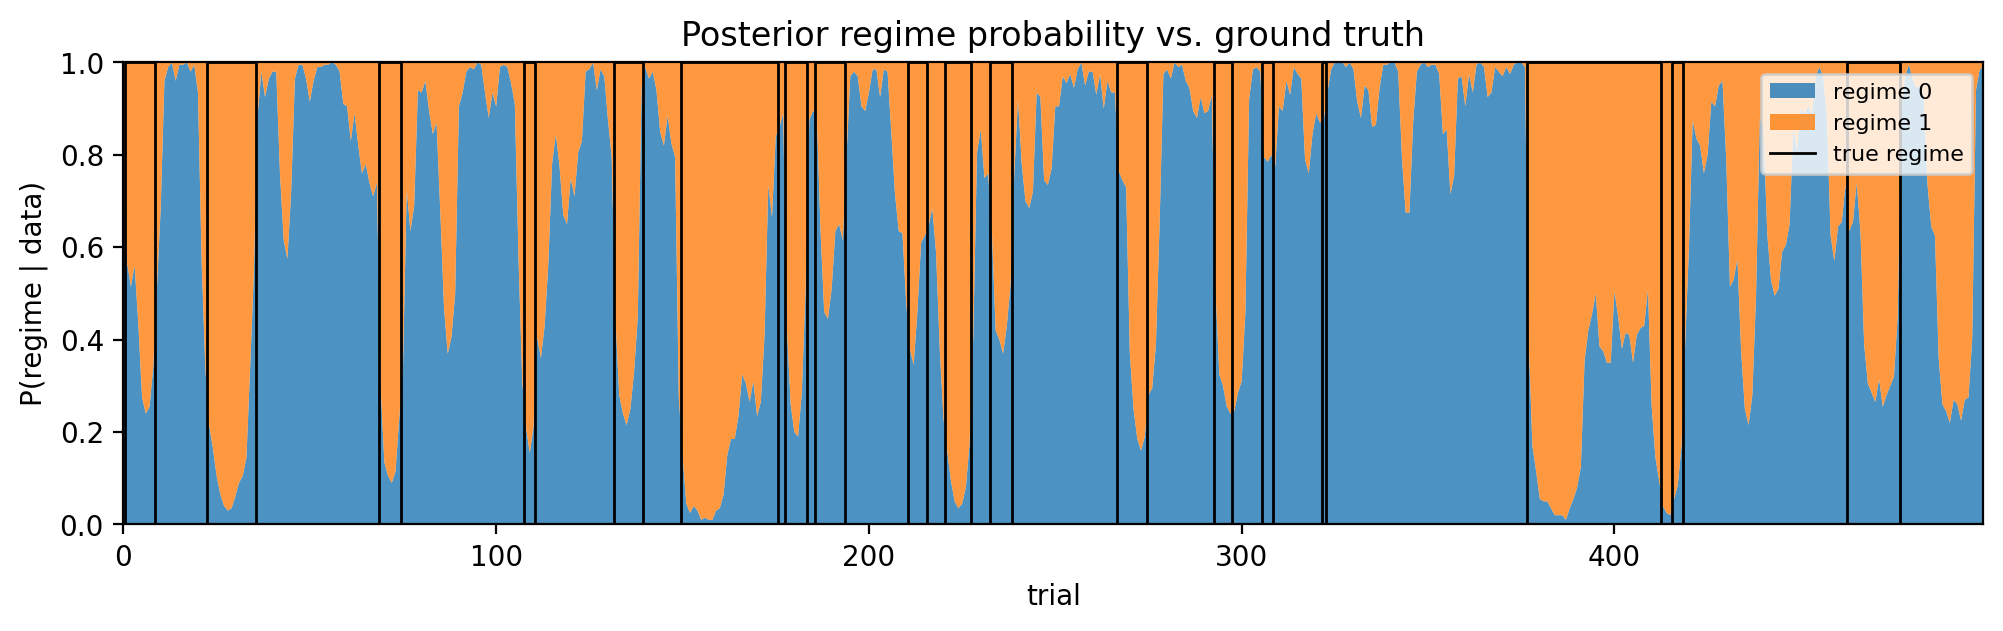

In [5]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)
ax = model.plot_regime_recovery(regimes_idata, true_regimes=true_regimes)
ax.set_title("Posterior regime probability vs. ground truth");

## 4. Per-trial log-likelihood and model comparison

The sampler contributes the likelihood as a single scalar, so the `log_likelihood` group needed by `arviz.loo` / `arviz.waic` is reconstructed post-hoc. Pass `include_log_likelihood=True` to `sample()` to attach it automatically, or call `compute_log_likelihood` directly.

In [6]:
model.compute_log_likelihood(idata)
az.loo(idata)

Computed from 1000 posterior samples and 500 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -474.20    24.19
p_loo        8.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.67]   (good)      500  100.0%
   (0.67, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%